In [1]:
import optuna
import pandas as pd
import numpy as np
import seaborn as sn
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import kpss

In [2]:
df=pd.read_csv("DATA/Backup/potato.csv")

df

,Date,price
0,2000-01-01 00:00:00,70.7
1,2000-02-01 00:00:00,58.6
2,2000-03-01 00:00:00,67.0
3,2000-04-01 00:00:00,68.7
4,2000-05-01 00:00:00,77.8
...,...,...
283,2023-08-01 00:00:00,221.4
284,2023-09-01 00:00:00,212.2
285,2023-10-01 00:00:00,209.7
286,2023-11-01 00:00:00,210.7


Missing values:
Date     0
price    0
dtype: int64

Duplicates:
0

Basic statistics of Price:
count    288.000000
mean     200.228472
std       77.393343
min       58.600000
25%      145.575000
50%      194.000000
75%      235.425000
max      491.100000
Name: price, dtype: float64


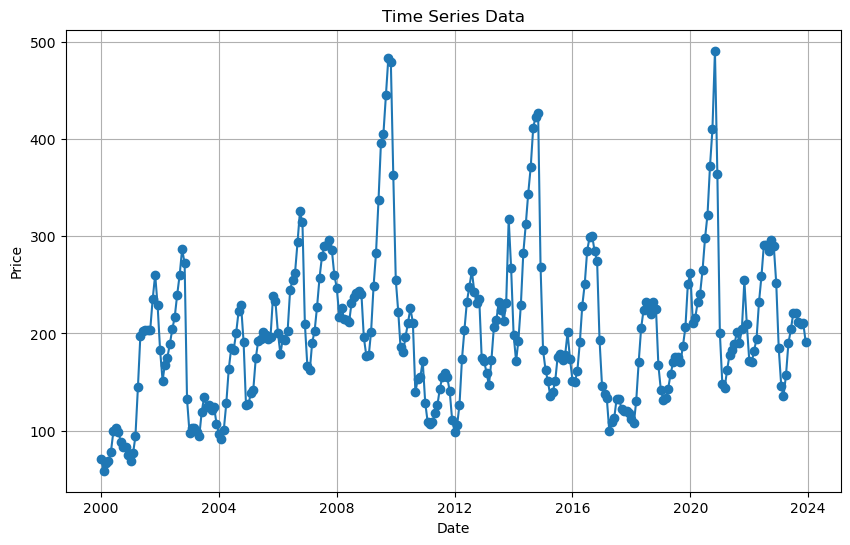

In [3]:
import pandas as pd


# Convert 'Date' column to datetime type
df['Date'] = pd.to_datetime(df['Date'])

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicates
print("\nDuplicates:")
print(df.duplicated().sum())

# Check basic statistics of the 'Price' column
print("\nBasic statistics of Price:")
print(df['price'].describe())

# Plot the time series data
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['price'], marker='o')
plt.title('Time Series Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()


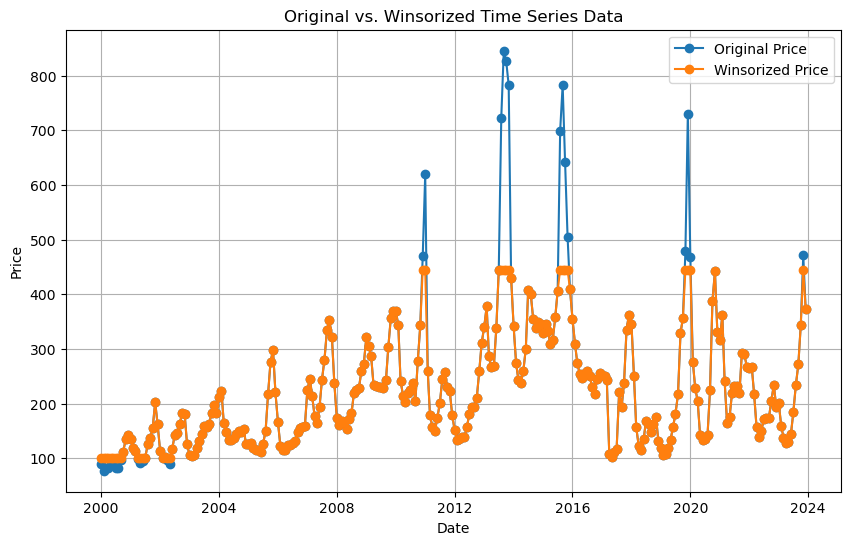

In [5]:
import pandas as pd
from scipy.stats import mstats
def winsorize_outliers(series, lower_percentile=0.05, upper_percentile=0.95):
    lower_limit = series.quantile(lower_percentile)
    upper_limit = series.quantile(upper_percentile)
    winsorized_values = mstats.winsorize(series, limits=(lower_percentile, 1 - upper_percentile))  # Correcting the upper percentile value
    return winsorized_values


# Winsorize the 'Price' column
#df['Price_winsorized'] = winsorize_outliers(df['price'])
df['price1'] = winsorize_outliers(df['price'], lower_percentile=0.05, upper_percentile=0.95)


# Plot the original and winsorized time series data
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['price'], marker='o', label='Original Price')
plt.plot(df['Date'], df['price1'], marker='o', label='Winsorized Price')
plt.title('Original vs. Winsorized Time Series Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


In [13]:
'''from statsmodels.tsa.seasonal import seasonal_decompose

# Seasonal decomposition
result = seasonal_decompose(df['price1'], model='additive', period=12)  # Assuming seasonality period of 12 months
detrended = df['price1'] - result.trend
seasonal = result.seasonal
residual = result.resid'''


"from statsmodels.tsa.seasonal import seasonal_decompose\n\n# Seasonal decomposition\nresult = seasonal_decompose(df['price1'], model='additive', period=12)  # Assuming seasonality period of 12 months\ndetrended = df['price1'] - result.trend\nseasonal = result.seasonal\nresidual = result.resid"

In [14]:
'''from sklearn.preprocessing import PowerTransformer

# Log transformation
df['Price_log'] = np.log(df['price1'])

# Box-Cox transformation
boxcox_transformer = PowerTransformer(method='box-cox')
df['Price_boxcox'] = boxcox_transformer.fit_transform(df['price1'].values.reshape(-1, 1))

# Quantile transformation (e.g., Gaussian transformation)
quantile_transformer = PowerTransformer(method='yeo-johnson')
df['Price_quantile'] = quantile_transformer.fit_transform(df['price1'].values.reshape(-1, 1))
'''

"from sklearn.preprocessing import PowerTransformer\n\n# Log transformation\ndf['Price_log'] = np.log(df['price1'])\n\n# Box-Cox transformation\nboxcox_transformer = PowerTransformer(method='box-cox')\ndf['Price_boxcox'] = boxcox_transformer.fit_transform(df['price1'].values.reshape(-1, 1))\n\n# Quantile transformation (e.g., Gaussian transformation)\nquantile_transformer = PowerTransformer(method='yeo-johnson')\ndf['Price_quantile'] = quantile_transformer.fit_transform(df['price1'].values.reshape(-1, 1))\n"

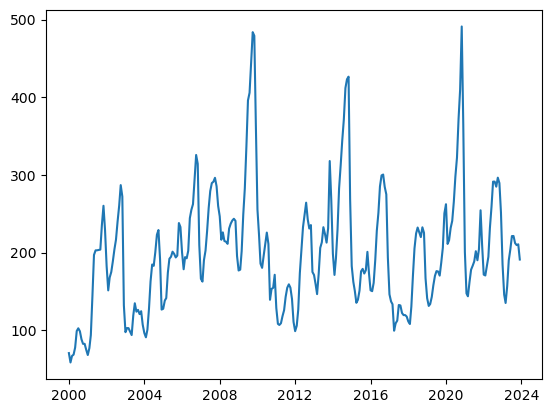

In [4]:
plt.plot(df['Date'],df['price'])

<Axes: >

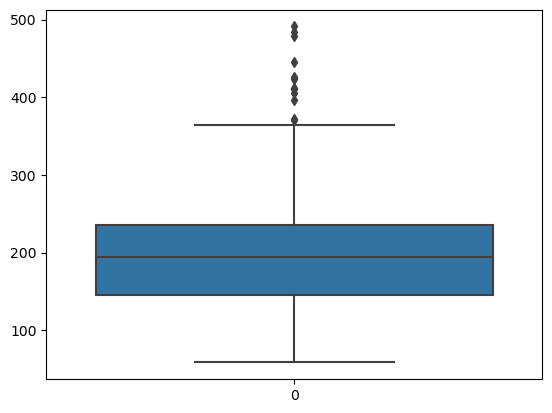

In [5]:
sn.boxplot(df['price'])

In [6]:
t=kpss(df['price'],'ct')
t

/var/folders/35/vcbg9sn9479dqrdl_3fgrrkh0000gn/T/ipykernel_97370/1514378212.py:1: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  t=kpss(df['price'],'ct')


(0.2919632085948914,
 0.01,
 9,
 {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216})

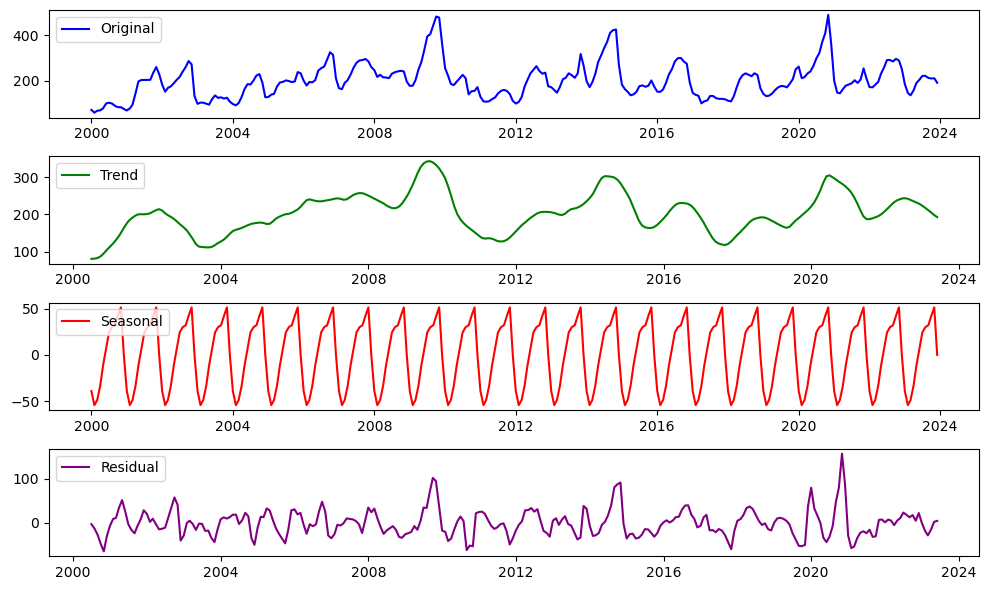

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Assuming df is your DataFrame with a 'date' column and a 'value' column representing the time series
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Perform seasonal decomposition
decomposition = seasonal_decompose(df['price'], model='additive')

# Plot the original time series
plt.figure(figsize=(10, 6))
plt.subplot(411)
plt.plot(df['price'], label='Original', color='blue')
plt.legend(loc='upper left')

# Plot the trend component
plt.subplot(412)
plt.plot(decomposition.trend, label='Trend', color='green')
plt.legend(loc='upper left')

# Plot the seasonal component
plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal', color='red')
plt.legend(loc='upper left')

# Plot the residual component
plt.subplot(414)
plt.plot(decomposition.resid, label='Residual', color='purple')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [8]:
from scipy.stats import skew, kurtosis, shapiro

df=pd.read_csv("DATA/Backup/potato.csv")

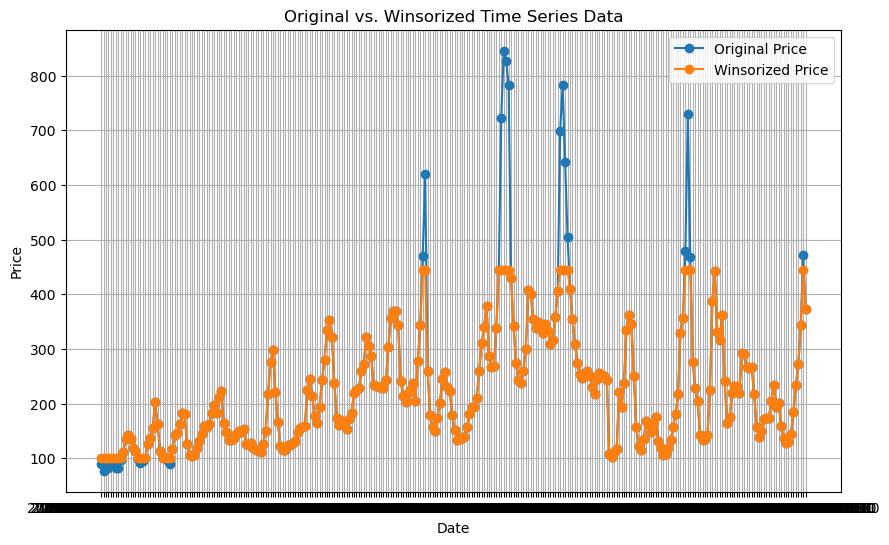

In [48]:
import pandas as pd
from scipy.stats import mstats
def winsorize_outliers(series, lower_percentile=0.05, upper_percentile=0.95):
    lower_limit = series.quantile(lower_percentile)
    upper_limit = series.quantile(upper_percentile)
    winsorized_values = mstats.winsorize(series, limits=(lower_percentile, 1 - upper_percentile))  # Correcting the upper percentile value
    return winsorized_values


# Winsorize the 'Price' column
#df['Price_winsorized'] = winsorize_outliers(df['price'])
df['price1'] = winsorize_outliers(df['price'], lower_percentile=0.05, upper_percentile=0.95)


# Plot the original and winsorized time series data
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['price'], marker='o', label='Original Price')
plt.plot(df['Date'], df['price1'], marker='o', label='Winsorized Price')
plt.title('Original vs. Winsorized Time Series Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

In [49]:
df.pop('price')
df['price']=df.pop('price1')
df

,Date,price
0,2000-01-01 00:00:00,100.8
1,2000-02-01 00:00:00,100.8
2,2000-03-01 00:00:00,100.8
3,2000-04-01 00:00:00,100.8
4,2000-05-01 00:00:00,100.8
...,...,...
283,2023-08-01 00:00:00,233.9
284,2023-09-01 00:00:00,271.9
285,2023-10-01 00:00:00,343.4
286,2023-11-01 00:00:00,445.3


<Axes: >

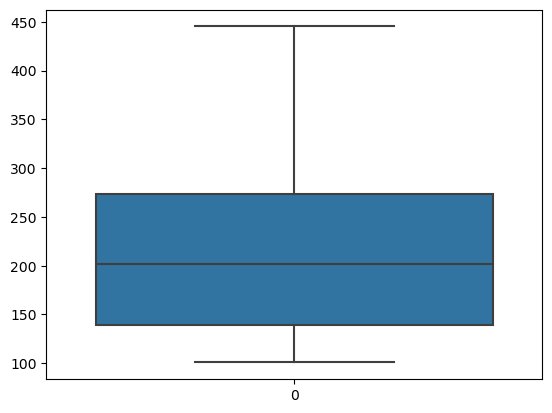

In [23]:
sn.boxplot(df['price'])

In [106]:
#df.pop('price')
#df['price']=df.pop('price1')
df1=df
df1

,Date,price
0,2000-01-01 00:00:00,166.9
1,2000-02-01 00:00:00,166.0
2,2000-03-01 00:00:00,166.6
3,2000-04-01 00:00:00,169.9
4,2000-05-01 00:00:00,171.0
...,...,...
283,2023-08-01 00:00:00,184.3
284,2023-09-01 00:00:00,187.0
285,2023-10-01 00:00:00,190.2
286,2023-11-01 00:00:00,191.4


In [9]:
skewness = skew(df['price'])
kurt = kurtosis(df['price'])

# Perform Shapiro-Wilk test for normality
shapiro_stat, shapiro_p_value = shapiro(df['price'])

# Print the results
print("Skewness:", skewness)
print("Kurtosis:", kurt)
print("Shapiro-Wilk Statistic:", shapiro_stat)
print("Shapiro-Wilk p-value:", shapiro_p_value)

Skewness: 1.0090555691533578
Kurtosis: 1.6981990206740027
Shapiro-Wilk Statistic: 0.9433034658432007
Shapiro-Wilk p-value: 4.406025322367668e-09


In [14]:
# Convert 'date' column to datetime if it's not already
# Shift the 'price' column to create new columns

scaler = MinMaxScaler(feature_range=(0, 1))
df['price'] = scaler.fit_transform(df['price'].values.reshape(-1,1))
#import matplotlib.pyplot as plt
#plt.plot(df['Date'],df['price'])


    

#dates_test, X_test, y_test = dates[q_80:], X[q_80:], y[q_80:]

#df['target-1'] = df['price'].shift(1)
#df['target-2'] = df['price'].shift(2)
#df['target-3'] = df['price'].shift(3)
#df['target-4'] = df['price'].shift(4)
#df['target-5'] = df['price'].shift(5)
#df['target-6'] = df['price'].shift(6)
#df['target-7'] = df['price'].shift(7)
#df['target-8'] = df['price'].shift(8)
#df['target-9'] = df['price'].shift(9)
#df['target-10'] = df['price'].shift(10)

In [11]:
#dates
#X
#y

In [45]:
import pandas as pd
from scipy.stats import mstats
def winsorize_outliers(series, lower_percentile=0.05, upper_percentile=0.95):
    lower_limit = series.quantile(lower_percentile)
    upper_limit = series.quantile(upper_percentile)
    winsorized_values = mstats.winsorize(series, limits=(lower_percentile, 1 - upper_percentile))  # Correcting the upper percentile value
    return winsorized_values

In [46]:
df=pd.read_csv("DATA/Backup/potato.csv")
scaler = MinMaxScaler(feature_range=(0, 1))
df['price'] = scaler.fit_transform(df['price'].values.reshape(-1,1))
df['price1'] = winsorize_outliers(df['price'], lower_percentile=0.05, upper_percentile=0.95)
df.pop('price')
df['price']=df.pop('price1')
shift=3
for i in range(shift,0,-1):
    df['target-'+str(i)] = df['price'].shift(i)
d=df[shift:]

def windowed_df_to_date_X_y(windowed_dataframe):
    df_as_np = windowed_dataframe.to_numpy()
    dates = df_as_np[:, 0]
    middle_matrix = df_as_np[:, 2:]
    X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))
    Y = df_as_np[:, 1:2]
    return dates, X.astype(np.float32), Y.astype(np.float32)

dates, X, y = windowed_df_to_date_X_y(d)
dates.shape, X.shape, y.shape

q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)
dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]
dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

In [47]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers.legacy import Adam
from tensorflow.keras import layers
from keras.callbacks import EarlyStopping
from keras.regularizers import l2

def objective(trial):
    # Define hyperparameters to tune
    #lstm_units = trial.suggest_int('lstm_units', 32, 256)
    #gru_units = trial.suggest_int('gru_units', 32, 256)
    dense_units = trial.suggest_int('dense_units', 16, 128)
    num_filters = trial.suggest_int('num_filters', 16, 128)
    kernel_size = trial.suggest_int('kernel_size', 3, 7)
    #num_lstm_layers = trial.suggest_int('num_lstm_layers', 1, 3)
    learning_rate = trial.suggest_categorical('learning_rate', [1e-5, 1e-4, 1e-3])

    # Construct the model
    #'''
    model = Sequential([
        layers.Input((shift, 1)),
        #layers.LSTM(lstm_units),
        #layers.Bidirectional(layers.LSTM(lstm_units)),
        #layers.GRU(gru_units),
        layers.Conv1D(num_filters, kernel_size, activation='relu',padding='same'),
        layers.MaxPooling1D(),
        layers.Flatten(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dense(1)
    ])
    '''
    model = Sequential()
    model.add(layers.Input((shift, 1)))
    for _ in range(num_lstm_layers):
        model.add(layers.LSTM(lstm_units, return_sequences=True))
    model.add(layers.Flatten())
    model.add(layers.Dense(dense_units, activation='relu'))
    model.add(layers.Dense(1))
    '''
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    # Compile the model
    model.compile(loss='mse', 
                  optimizer=Adam(learning_rate=learning_rate),
                  metrics=['mean_absolute_error'])

    # Train the model
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200,callbacks=[early_stopping])

    # Evaluate the model on the validation set and return the validation loss
    loss = model.evaluate(X_val, y_val)[0]
    return loss


In [48]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)
best_params = study.best_params
print("Best hyperparameters:", best_params)


[I 2024-03-11 16:23:46,396] A new study created in memory with name: no-name-cc6b5fb8-1106-4b57-a0d9-f41a82a59c5a


Epoch 1/200
8/8 [==============================] - 0s 12ms/step - loss: 0.0567 - mean_absolute_error: 0.1999 - val_loss: 0.0363 - val_mean_absolute_error: 0.1653
Epoch 2/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0159 - mean_absolute_error: 0.1012 - val_loss: 0.0145 - val_mean_absolute_error: 0.0872
Epoch 3/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0120 - mean_absolute_error: 0.0876 - val_loss: 0.0147 - val_mean_absolute_error: 0.0821
Epoch 4/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0117 - mean_absolute_error: 0.0862 - val_loss: 0.0131 - val_mean_absolute_error: 0.0825
Epoch 5/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0098 - mean_absolute_error: 0.0802 - val_loss: 0.0132 - val_mean_absolute_error: 0.0875
Epoch 6/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0090 - mean_absolute_error: 0.0766 - val_loss: 0.0115 - val_mean_absolute_error: 0.0771
Epoch 7/200
8/8 [================

8/8 [==============================] - 0s 2ms/step - loss: 0.0032 - mean_absolute_error: 0.0419 - val_loss: 0.0048 - val_mean_absolute_error: 0.0420
Epoch 52/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0036 - mean_absolute_error: 0.0422 - val_loss: 0.0051 - val_mean_absolute_error: 0.0510
Epoch 53/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0032 - mean_absolute_error: 0.0414 - val_loss: 0.0047 - val_mean_absolute_error: 0.0429
Epoch 54/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0033 - mean_absolute_error: 0.0407 - val_loss: 0.0050 - val_mean_absolute_error: 0.0498
Epoch 55/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0032 - mean_absolute_error: 0.0421 - val_loss: 0.0048 - val_mean_absolute_error: 0.0412
Epoch 56/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0036 - mean_absolute_error: 0.0423 - val_loss: 0.0055 - val_mean_absolute_error: 0.0554
Epoch 57/200
8/8 [=======================

8/8 [==============================] - 0s 4ms/step - loss: 0.0029 - mean_absolute_error: 0.0391 - val_loss: 0.0044 - val_mean_absolute_error: 0.0403
Epoch 102/200
8/8 [==============================] - 0s 4ms/step - loss: 0.0028 - mean_absolute_error: 0.0375 - val_loss: 0.0047 - val_mean_absolute_error: 0.0462
Epoch 103/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0029 - mean_absolute_error: 0.0389 - val_loss: 0.0046 - val_mean_absolute_error: 0.0384
Epoch 104/200
8/8 [==============================] - 0s 4ms/step - loss: 0.0032 - mean_absolute_error: 0.0403 - val_loss: 0.0045 - val_mean_absolute_error: 0.0429
Epoch 105/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0032 - mean_absolute_error: 0.0402 - val_loss: 0.0051 - val_mean_absolute_error: 0.0523
Epoch 106/200
8/8 [==============================] - 0s 3ms/step - loss: 0.0030 - mean_absolute_error: 0.0400 - val_loss: 0.0045 - val_mean_absolute_error: 0.0388
Epoch 107/200
1/1 [=================

[I 2024-03-11 16:23:49,309] Trial 0 finished with value: 0.004371691960841417 and parameters: {'dense_units': 44, 'num_filters': 80, 'kernel_size': 3, 'learning_rate': 0.001}. Best is trial 0 with value: 0.004371691960841417.


...

[I 2024-03-11 16:27:34,725] Trial 98 finished with value: 0.004649586044251919 and parameters: {'dense_units': 33, 'num_filters': 56, 'kernel_size': 5, 'learning_rate': 0.001}. Best is trial 42 with value: 0.004285159055143595.


Epoch 1/200
8/8 [==============================] - 0s 8ms/step - loss: 0.0972 - mean_absolute_error: 0.2687 - val_loss: 0.0600 - val_mean_absolute_error: 0.2112
Epoch 2/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0232 - mean_absolute_error: 0.1169 - val_loss: 0.0163 - val_mean_absolute_error: 0.0948
Epoch 3/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0140 - mean_absolute_error: 0.0940 - val_loss: 0.0177 - val_mean_absolute_error: 0.0899
Epoch 4/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0142 - mean_absolute_error: 0.0938 - val_loss: 0.0147 - val_mean_absolute_error: 0.0854
Epoch 5/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0112 - mean_absolute_error: 0.0865 - val_loss: 0.0169 - val_mean_absolute_error: 0.1017
Epoch 6/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0115 - mean_absolute_error: 0.0879 - val_loss: 0.0153 - val_mean_absolute_error: 0.0956
Epoch 7/200
8/8 [=================

8/8 [==============================] - 0s 2ms/step - loss: 0.0032 - mean_absolute_error: 0.0405 - val_loss: 0.0050 - val_mean_absolute_error: 0.0489
Epoch 52/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0032 - mean_absolute_error: 0.0415 - val_loss: 0.0048 - val_mean_absolute_error: 0.0456
Epoch 53/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0032 - mean_absolute_error: 0.0399 - val_loss: 0.0049 - val_mean_absolute_error: 0.0479
Epoch 54/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0036 - mean_absolute_error: 0.0455 - val_loss: 0.0049 - val_mean_absolute_error: 0.0396
Epoch 55/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0036 - mean_absolute_error: 0.0436 - val_loss: 0.0053 - val_mean_absolute_error: 0.0531
Epoch 56/200
8/8 [==============================] - 0s 2ms/step - loss: 0.0032 - mean_absolute_error: 0.0407 - val_loss: 0.0048 - val_mean_absolute_error: 0.0434
Epoch 57/200
8/8 [=======================

[I 2024-03-11 16:27:36,387] Trial 99 finished with value: 0.004448369611054659 and parameters: {'dense_units': 68, 'num_filters': 71, 'kernel_size': 3, 'learning_rate': 0.001}. Best is trial 42 with value: 0.004285159055143595.


Best hyperparameters: {'dense_units': 46, 'num_filters': 64, 'kernel_size': 3, 'learning_rate': 0.001}


In [49]:
best_params


{'dense_units': 46,
 'num_filters': 64,
 'kernel_size': 3,
 'learning_rate': 0.001}

In [58]:
#best_lstm_units = best_params['lstm_units']
best_dense_units = best_params['dense_units']
#best_gru_units = best_params['gru_units']
best_learning_rate = best_params['learning_rate']
num_filters = best_params['num_filters']
kernel_size = best_params['kernel_size']
#best_num_lstm_layers = best_params['num_lstm_layers']
#'''
model = Sequential([
    layers.Input((shift, 1)),
    #layers.LSTM(best_lstm_units),
    #layers.Bidirectional(layers.LSTM(best_lstm_units)),
    #layers.GRU(best_gru_units),
    layers.Conv1D(num_filters, kernel_size, activation='relu',padding='same'),
    layers.MaxPooling1D(),
    layers.Flatten(),
    layers.Dense(best_dense_units, activation='relu'),
    layers.Dense(1)
])
'''
model = Sequential()
model.add(layers.Input((shift, 1)))
for _ in range(best_num_lstm_layers):
    model.add(layers.LSTM(best_lstm_units, return_sequences=True))
model.add(layers.Flatten())
model.add(layers.Dense(best_dense_units, activation='relu'))
model.add(layers.Dense(1))
#'''

# Compile the final model
model.compile(loss='mse', 
                optimizer=Adam(learning_rate=best_learning_rate),
                metrics=['mean_absolute_error'])

# Train the final model on the entire training data
h=model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=250)


    

Epoch 1/250
8/8 [==============================] - 0s 9ms/step - loss: 0.0872 - mean_absolute_error: 0.2525 - val_loss: 0.0595 - val_mean_absolute_error: 0.2102
Epoch 2/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0249 - mean_absolute_error: 0.1229 - val_loss: 0.0183 - val_mean_absolute_error: 0.1080
Epoch 3/250
8/8 [==============================] - 0s 3ms/step - loss: 0.0116 - mean_absolute_error: 0.0871 - val_loss: 0.0143 - val_mean_absolute_error: 0.0838
Epoch 4/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0127 - mean_absolute_error: 0.0899 - val_loss: 0.0138 - val_mean_absolute_error: 0.0816
Epoch 5/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0109 - mean_absolute_error: 0.0842 - val_loss: 0.0134 - val_mean_absolute_error: 0.0858
Epoch 6/250
8/8 [==============================] - 0s 3ms/step - loss: 0.0100 - mean_absolute_error: 0.0819 - val_loss: 0.0136 - val_mean_absolute_error: 0.0896
Epoch 7/250
8/8 [=================

8/8 [==============================] - 0s 2ms/step - loss: 0.0035 - mean_absolute_error: 0.0420 - val_loss: 0.0051 - val_mean_absolute_error: 0.0471
Epoch 52/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0034 - mean_absolute_error: 0.0411 - val_loss: 0.0053 - val_mean_absolute_error: 0.0518
Epoch 53/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0035 - mean_absolute_error: 0.0443 - val_loss: 0.0051 - val_mean_absolute_error: 0.0452
Epoch 54/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0035 - mean_absolute_error: 0.0413 - val_loss: 0.0055 - val_mean_absolute_error: 0.0551
Epoch 55/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0039 - mean_absolute_error: 0.0470 - val_loss: 0.0052 - val_mean_absolute_error: 0.0514
Epoch 56/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0033 - mean_absolute_error: 0.0429 - val_loss: 0.0052 - val_mean_absolute_error: 0.0525
Epoch 57/250
8/8 [=======================

8/8 [==============================] - 0s 2ms/step - loss: 0.0029 - mean_absolute_error: 0.0374 - val_loss: 0.0046 - val_mean_absolute_error: 0.0420
Epoch 102/250
8/8 [==============================] - 0s 3ms/step - loss: 0.0029 - mean_absolute_error: 0.0380 - val_loss: 0.0046 - val_mean_absolute_error: 0.0434
Epoch 103/250
8/8 [==============================] - 0s 3ms/step - loss: 0.0030 - mean_absolute_error: 0.0379 - val_loss: 0.0046 - val_mean_absolute_error: 0.0443
Epoch 104/250
8/8 [==============================] - 0s 3ms/step - loss: 0.0030 - mean_absolute_error: 0.0396 - val_loss: 0.0045 - val_mean_absolute_error: 0.0412
Epoch 105/250
8/8 [==============================] - 0s 5ms/step - loss: 0.0030 - mean_absolute_error: 0.0382 - val_loss: 0.0046 - val_mean_absolute_error: 0.0441
Epoch 106/250
8/8 [==============================] - 0s 3ms/step - loss: 0.0028 - mean_absolute_error: 0.0376 - val_loss: 0.0045 - val_mean_absolute_error: 0.0409
Epoch 107/250
8/8 [=================

8/8 [==============================] - 0s 2ms/step - loss: 0.0027 - mean_absolute_error: 0.0370 - val_loss: 0.0045 - val_mean_absolute_error: 0.0369
Epoch 152/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0031 - mean_absolute_error: 0.0381 - val_loss: 0.0048 - val_mean_absolute_error: 0.0482
Epoch 153/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0027 - mean_absolute_error: 0.0379 - val_loss: 0.0044 - val_mean_absolute_error: 0.0375
Epoch 154/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0029 - mean_absolute_error: 0.0377 - val_loss: 0.0047 - val_mean_absolute_error: 0.0467
Epoch 155/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0028 - mean_absolute_error: 0.0380 - val_loss: 0.0044 - val_mean_absolute_error: 0.0388
Epoch 156/250
8/8 [==============================] - 0s 2ms/step - loss: 0.0027 - mean_absolute_error: 0.0368 - val_loss: 0.0045 - val_mean_absolute_error: 0.0434
Epoch 157/250
8/8 [=================

8/8 [==============================] - 0s 2ms/step - loss: 0.0031 - mean_absolute_error: 0.0399 - val_loss: 0.0049 - val_mean_absolute_error: 0.0503
Epoch 202/250
8/8 [==============================] - 0s 3ms/step - loss: 0.0029 - mean_absolute_error: 0.0399 - val_loss: 0.0044 - val_mean_absolute_error: 0.0401
Epoch 203/250
8/8 [==============================] - 0s 3ms/step - loss: 0.0030 - mean_absolute_error: 0.0399 - val_loss: 0.0045 - val_mean_absolute_error: 0.0445
Epoch 204/250
8/8 [==============================] - 0s 3ms/step - loss: 0.0028 - mean_absolute_error: 0.0382 - val_loss: 0.0045 - val_mean_absolute_error: 0.0450
Epoch 205/250
8/8 [==============================] - 0s 3ms/step - loss: 0.0029 - mean_absolute_error: 0.0400 - val_loss: 0.0044 - val_mean_absolute_error: 0.0404
Epoch 206/250
8/8 [==============================] - 0s 3ms/step - loss: 0.0028 - mean_absolute_error: 0.0378 - val_loss: 0.0044 - val_mean_absolute_error: 0.0419
Epoch 207/250
8/8 [=================

Training Loss: [0.002681876067072153, 0.03627092018723488]
Testing Loss: [0.0023826677352190018, 0.03531529754400253]


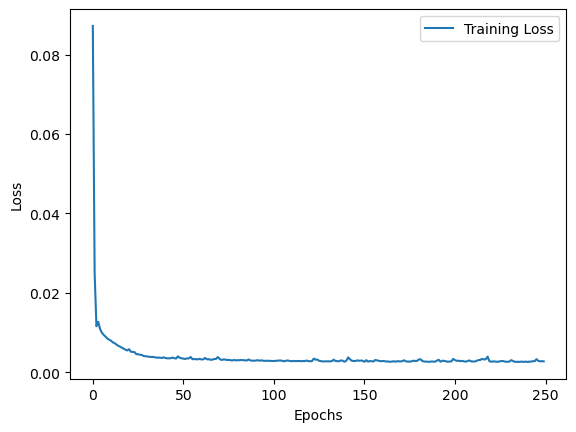

In [59]:
train_loss = model.evaluate(X_train, y_train, verbose=0)
print(f'Training Loss: {train_loss}')
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f'Testing Loss: {test_loss}')
plt.plot(h.history['loss'], label='Training Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

8/8 [==============================] - 0s 547us/step


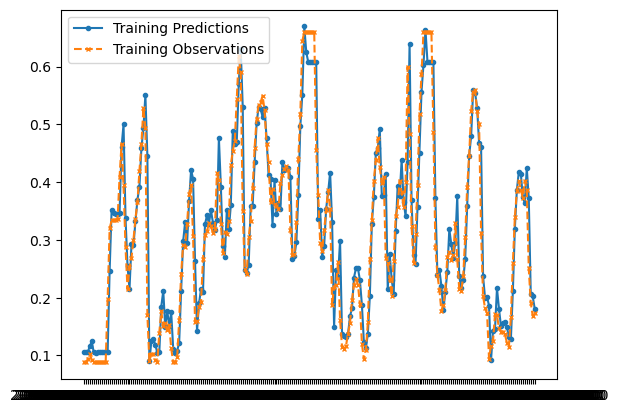

In [60]:
train_predictions = model.predict(X_train)

plt.plot(dates_train, train_predictions,linestyle="-", marker='o', markersize=3)
plt.plot(dates_train, y_train, linestyle="--", marker='x', markersize=3)

##plt.plot(train_predictions)
##plt.plot(y_train)
plt.legend(['Training Predictions', 'Training Observations'])

1/1 [==============================] - 0s 10ms/step


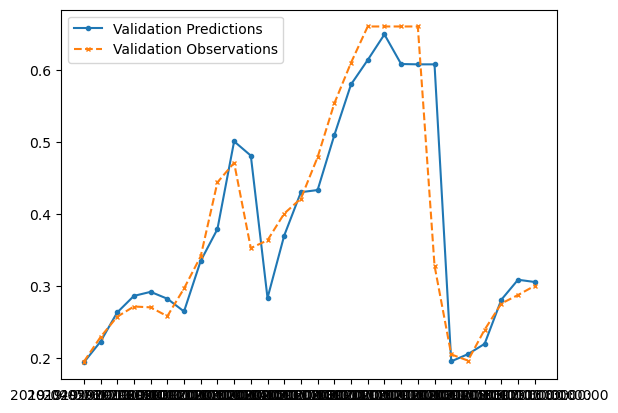

In [61]:
val_predictions = model.predict(X_val)#.flatten()

plt.plot(dates_val, val_predictions,linestyle="-", marker='o', markersize=3)
plt.plot(dates_val, y_val,linestyle="--", marker='x', markersize=3)
plt.legend(['Validation Predictions', 'Validation Observations'])

1/1 [==============================] - 0s 11ms/step


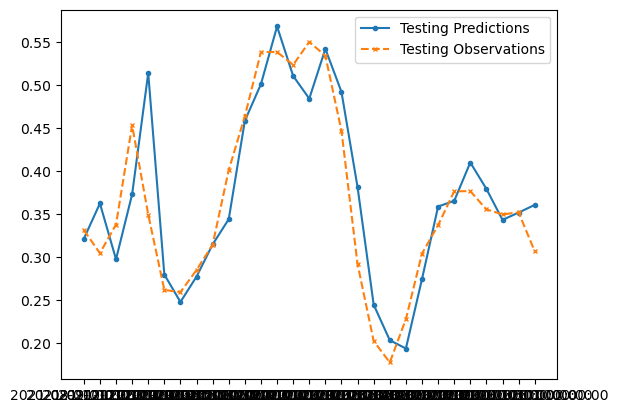

In [62]:
test_predictions = model.predict(X_test)#.flatten()

plt.plot(dates_test, test_predictions,linestyle="-", marker='o', markersize=3)
plt.plot(dates_test, y_test,linestyle="--", marker='x', markersize=3)
plt.legend(['Testing Predictions', 'Testing Observations'])

In [63]:
#test_predictions

In [64]:
# Inverse transform to get actual prices
y_train_actual = scaler.inverse_transform(y_train.reshape(-1, 1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_train_pred_actual = scaler.inverse_transform(train_predictions.reshape(-1,1))
y_test_pred_actual = scaler.inverse_transform(test_predictions.reshape(-1,1))
y_val_pred_actual = scaler.inverse_transform(val_predictions.reshape(-1,1))
y_val_actual = scaler.inverse_transform(y_val.reshape(-1,1))


In [65]:
# Calculate evaluation metrics
train_mae = mean_absolute_error(y_train_actual, y_train_pred_actual)
train_mse = mean_squared_error(y_train_actual, y_train_pred_actual)
val_mae = mean_absolute_error(y_val_actual, y_val_pred_actual)
test_mae = mean_absolute_error(y_test_actual, y_test_pred_actual)
test_mse = mean_squared_error(y_test_actual, y_test_pred_actual)
val_mse = mean_squared_error(y_val_actual, y_val_pred_actual)

print(f'Training MAE: {train_mae}')
print(f'Training MSE: {train_mse}')
print(f'Val MAE: {val_mae}')
print(f'Val MSE: {val_mse}')
print(f'Testing MAE: {test_mae}')
print(f'Testing MSE: {test_mse}')


train_r = np.sqrt(train_mse)
train_r2 = r2_score(y_train_actual, y_train_pred_actual)
test_r = np.sqrt(test_mse)
test_r2 = r2_score(y_test_actual, y_test_pred_actual)
val_r = np.sqrt(val_mse)
val_r2 = r2_score(y_val_actual, y_val_pred_actual)


print(f'Training RMSE:{train_r}')
print(f'Training R-square :{train_r2}')
print(f'Validation RMSE:{val_r}')
print(f'Validation R-square :{val_r2}')
print(f'Testing RMSE:{test_r}')
print(f'Testing R-square :{test_r2}')

Training MAE: 15.687170028686523
Training MSE: 501.66162109375
Val MAE: 16.742155075073242
Val MSE: 820.22998046875
Testing MAE: 15.273862838745117
Testing MSE: 445.69268798828125
Training RMSE:22.397804260253906
Training R-square :0.8877053780030175
Validation RMSE:28.639657974243164
Validation R-square :0.8115676437274943
Testing RMSE:21.111434936523438
Testing R-square :0.7733956788445925


In [66]:
model.save('potato_cnn')

INFO:tensorflow:Assets written to: potato_cnn/assets


INFO:tensorflow:Assets written to: potato_cnn/assets


In [69]:
import tensorflow as tf
m1=tf.keras.models.load_model('potato_cnn')
m1.layers[0].input_shape

(None, 3, 1)

In [70]:
test_predictions = m1.predict(X_test)#.flatten()

y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
y_test_pred_actual = scaler.inverse_transform(test_predictions.reshape(-1,1))

test_r2 = r2_score(y_test_actual, y_test_pred_actual)
print(test_r2)
#plt.plot(dates_test, test_predictions)
#plt.plot(dates_test, y_test)
#plt.legend(['Testing Predictions', 'Testing Observations'])

1/1 [==============================] - 0s 32ms/step
0.7733956788445925


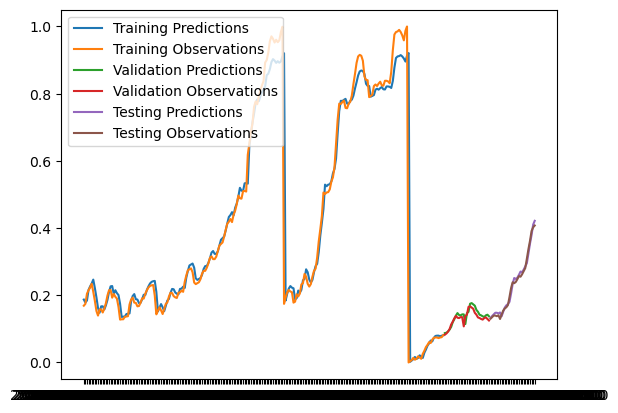

In [132]:
plt.plot(figsize=(100,100))
plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Training Predictions', 
            'Training Observations',
            'Validation Predictions', 
            'Validation Observations',
            'Testing Predictions', 
            'Testing Observations'],loc='upper left')



In [81]:
n = 12  # Change this value to forecast more or fewer values
forecast = []
last_data = X[-1]  # Last X data point
for i in range(n):
    next_y = model.predict(last_data.reshape(1, X.shape[1], X.shape[2]))  # Predict next y
    forecast.append(next_y)
    last_data = np.append(last_data[1:], next_y)  # Shift data by 1 and append next_y
forecast = scaler.inverse_transform(np.array(forecast).reshape(-1, 1))
y_act=scaler.inverse_transform(np.array(y).reshape(-1, 1))

1/1 [==============================] - 0s 9ms/step


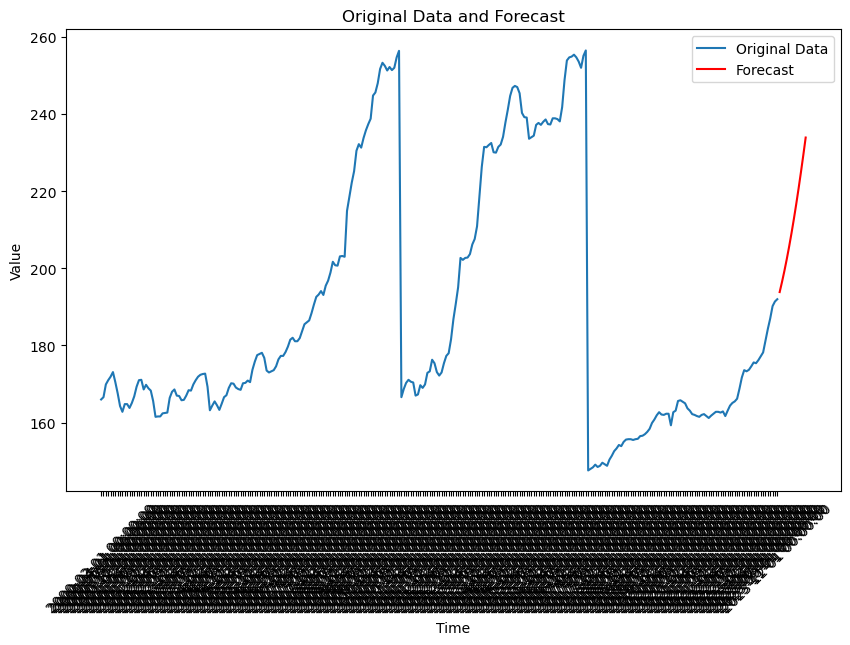

In [82]:
plt.figure(figsize=(10, 6))
plt.plot(dates, y_act, label='Original Data')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title('Original Data and Forecast')
plt.xticks(rotation=45)
plt.legend()

# Plot forecast
forecast_dates = np.arange(len(y), len(y) + n)
plt.plot(forecast_dates, forecast, label='Forecast', color='red')
plt.legend()

plt.show()